<a href="https://colab.research.google.com/github/SarahBour/ROGII---Wellbore-Geology-Prediction/blob/main/rogii-wellbore-geology-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Dependencies

In [ ]:
# import all libraries and functions here ...
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
from scipy.signal import correlate
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

# 2. Exploratory Data Analysis

In [ ]:
# constants
#directories
DATA_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"
TRAIN_DIR = DATA_DIR + "/train"
TEST_DIR = DATA_DIR + "/test"

#files
HORIZONTAL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__horizontal_well.csv"))
TYPEWELL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__typewell.csv"))

WINDOW = 25 # for cross correlation
ROLLING_WINDOW = 30

In [ ]:
# code to see all files in the data/ input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

In [ ]:
# check horizontal csv file
def get_horizontal_file():
    file_path = random.choice(HORIZONTAL_FILES)
    df = pd.read_csv(file_path)
    well_ID = os.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df, well_ID

In [ ]:
# check typewell csv file
def get_typewell_file():
    file_path = random.choice(TYPEWELL_FILES)
    df = pd.read_csv(file_path)
    well_ID = os.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df

In [ ]:
# get matching typewell file
def get_matching_files():
    horizontal_df, well_ID  = get_horizontal_file()
    typewell_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")
    typewell_df = pd.read_csv(typewell_file)
    return horizontal_df, well_ID,typewell_df

In [ ]:
h_df, ID , tw_df = get_matching_files()

In [ ]:
h_df.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,10181.0,2938546.84,1069371.80,-7992.85,-8209.75,-8365.71,-8442.46,-8532.04,-8576.74,-8681.8,10145.51,89.649978,10145.51,35b3ef6a
1,10182.0,2938546.84,1069371.81,-7993.85,-8209.75,-8365.71,-8442.46,-8532.04,-8576.74,-8681.8,10146.51,98.253622,10146.51,35b3ef6a
2,10183.0,2938546.84,1069371.82,-7994.85,-8209.75,-8365.71,-8442.46,-8532.04,-8576.74,-8681.8,10147.51,91.370707,10147.51,35b3ef6a
3,10184.0,2938546.84,1069371.84,-7995.85,-8209.75,-8365.71,-8442.46,-8532.04,-8576.74,-8681.8,10148.51,92.463370,10148.51,35b3ef6a
4,10185.0,2938546.84,1069371.85,-7996.85,-8209.75,-8365.71,-8442.45,-8532.04,-8576.74,-8681.8,10149.51,96.102711,10149.51,35b3ef6a


In [ ]:
tw_df.head()

,TVT,GR,Geology
0,10133.16,109.80,NaN
1,10133.66,109.35,NaN
2,10134.16,107.39,NaN
3,10134.66,106.17,NaN
4,10135.16,106.75,NaN


In [ ]:
h_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5736 entries, 0 to 5735
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         5736 non-null   float64
 1   X          5736 non-null   float64
 2   Y          5736 non-null   float64
 3   Z          5736 non-null   float64
 4   ANCC       5736 non-null   float64
 5   ASTNU      5736 non-null   float64
 6   ASTNL      5736 non-null   float64
 7   EGFDU      5736 non-null   float64
 8   EGFDL      5736 non-null   float64
 9   BUDA       5736 non-null   float64
 10  TVT        5736 non-null   float64
 11  GR         3689 non-null   float64
 12  TVT_input  1832 non-null   float64
 13  WELL_ID    5736 non-null   object 
dtypes: float64(13), object(1)
memory usage: 627.5+ KB


In [ ]:
h_df.describe()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
count,5736.000000,5.736000e+03,5.736000e+03,5736.000000,5736.000000,5736.000000,5736.000000,5736.000000,5736.000000,5736.000000,5736.000000,3689.000000,1832.000000
mean,13048.500000,2.936902e+06,1.071294e+06,-8461.614669,-8092.175601,-8248.137510,-8324.883291,-8414.464644,-8459.169474,-8564.227934,10731.848089,83.048853,10663.675202
std,1655.984903,1.062381e+03,1.232896e+03,109.236062,73.253589,73.253589,73.253539,73.253607,73.253538,73.253593,116.971746,14.064705,189.195631
min,10181.000000,2.935037e+06,1.069372e+06,-8606.650000,-8209.750000,-8365.710000,-8442.460000,-8532.040000,-8576.740000,-8681.800000,10145.510000,37.167745,10145.510000
25%,11614.750000,2.936003e+06,1.070197e+06,-8541.237500,-8153.650000,-8309.610000,-8386.357500,-8475.937500,-8520.640000,-8625.700000,10752.200000,73.492333,10569.437500
50%,13048.500000,2.936887e+06,1.071263e+06,-8473.780000,-8094.690000,-8250.655000,-8327.395000,-8416.980000,-8461.685000,-8566.745000,10760.560000,83.627426,10786.725000
75%,14482.250000,2.937842e+06,1.072387e+06,-8396.180000,-8030.912500,-8186.872500,-8263.620000,-8353.202500,-8397.902500,-8502.962500,10776.817500,93.822745,10792.940000
max,15916.000000,2.938547e+06,1.073441e+06,-7992.850000,-7963.690000,-8119.650000,-8196.390000,-8285.970000,-8330.680000,-8435.740000,10799.360000,142.132210,10799.360000


In [ ]:
tw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      1498 non-null   float64
 1   GR       1498 non-null   float64
 2   Geology  1039 non-null   object 
dtypes: float64(2), object(1)
memory usage: 35.2+ KB


In [ ]:
tw_df['Geology']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
1493    BUDA
1494    BUDA
1495    BUDA
1496    BUDA
1497    BUDA
Name: Geology, Length: 1498, dtype: object

In [ ]:
# another well
h_df_1, _, tw_df_1 = get_matching_files()

In [ ]:
h_df_1.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,10469.0,2943312.10,1065913.58,-8323.37,-8416.65,-8572.61,-8649.36,-8738.94,-8783.64,-8888.70,10269.13,106.211874,10269.13,54753541
1,10470.0,2943312.45,1065913.39,-8324.29,-8416.56,-8572.52,-8649.27,-8738.85,-8783.55,-8888.61,10270.14,106.201966,10270.14,54753541
2,10471.0,2943312.80,1065913.20,-8325.20,-8416.47,-8572.43,-8649.17,-8738.76,-8783.46,-8888.52,10271.14,114.138133,10271.14,54753541
3,10472.0,2943313.15,1065913.01,-8326.12,-8416.38,-8572.34,-8649.08,-8738.67,-8783.37,-8888.43,10272.15,110.630763,10272.15,54753541
4,10473.0,2943313.51,1065912.82,-8327.03,-8416.29,-8572.25,-8648.99,-8738.57,-8783.28,-8888.34,10273.16,111.245048,10273.16,54753541


In [ ]:
h_df_1.shape

(5679, 14)

In [ ]:
h_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5679 entries, 0 to 5678
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         5679 non-null   float64
 1   X          5679 non-null   float64
 2   Y          5679 non-null   float64
 3   Z          5679 non-null   float64
 4   ANCC       5679 non-null   float64
 5   ASTNU      5679 non-null   float64
 6   ASTNL      5679 non-null   float64
 7   EGFDU      5679 non-null   float64
 8   EGFDL      5679 non-null   float64
 9   BUDA       5679 non-null   float64
 10  TVT        5679 non-null   float64
 11  GR         4160 non-null   float64
 12  TVT_input  1653 non-null   float64
 13  WELL_ID    5679 non-null   object 
dtypes: float64(13), object(1)
memory usage: 621.3+ KB


In [ ]:
tw_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1251 entries, 0 to 1250
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      1251 non-null   float64
 1   GR       1251 non-null   float64
 2   Geology  1039 non-null   object 
dtypes: float64(2), object(1)
memory usage: 29.4+ KB


In [ ]:
def plot_x_y(x, y, x_label , y_label, title):
    plt.figure(figsize = (20,8))
    plt.plot(x, y, linewidth = 0.8)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha = 0.3)
    plt.show()

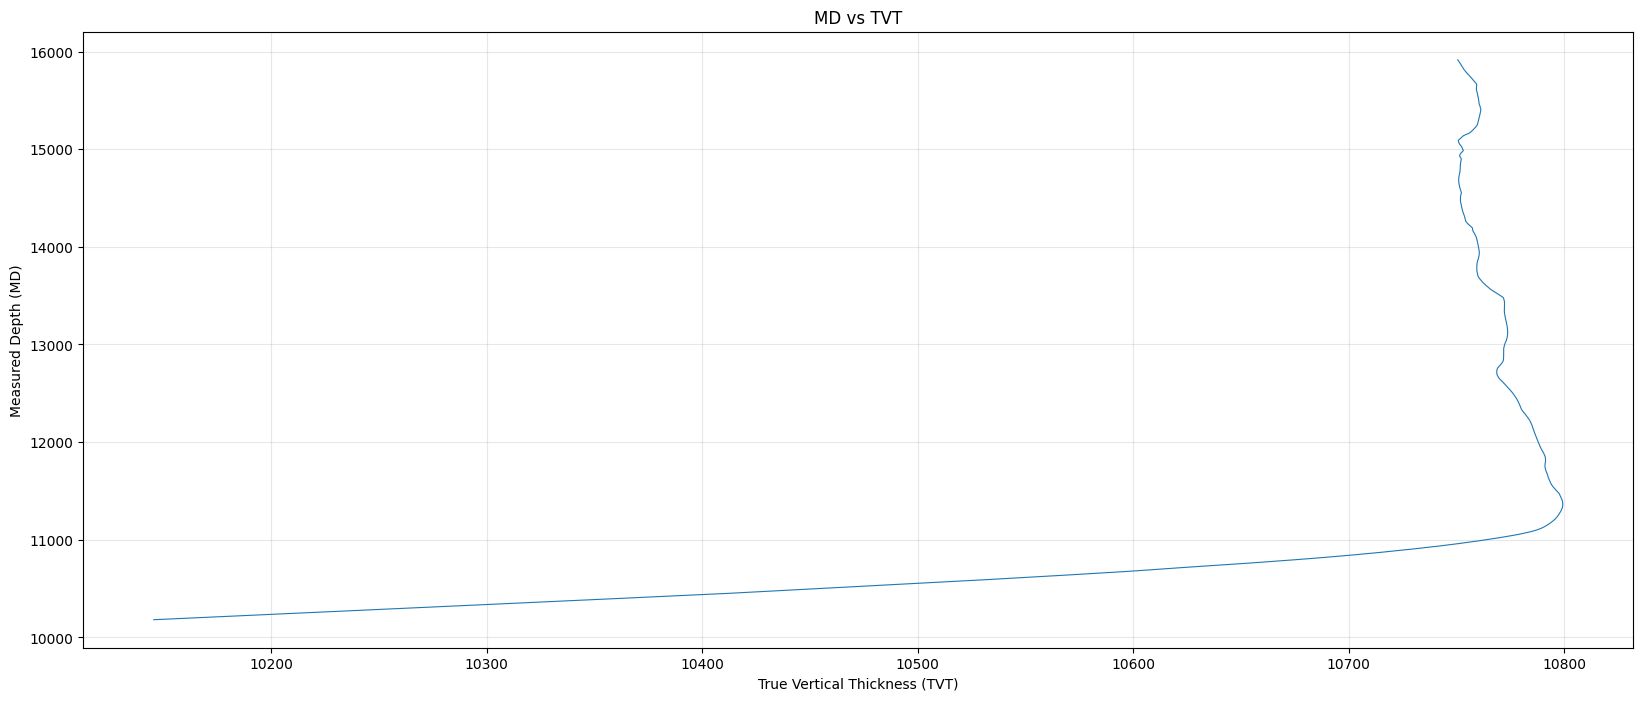

In [ ]:
# MD against TVT
# illustrates where the horizontal drilling starts (?)
plot_x_y(h_df['TVT'], h_df['MD'], "True Vertical Thickness (TVT)", "Measured Depth (MD)", "MD vs TVT")

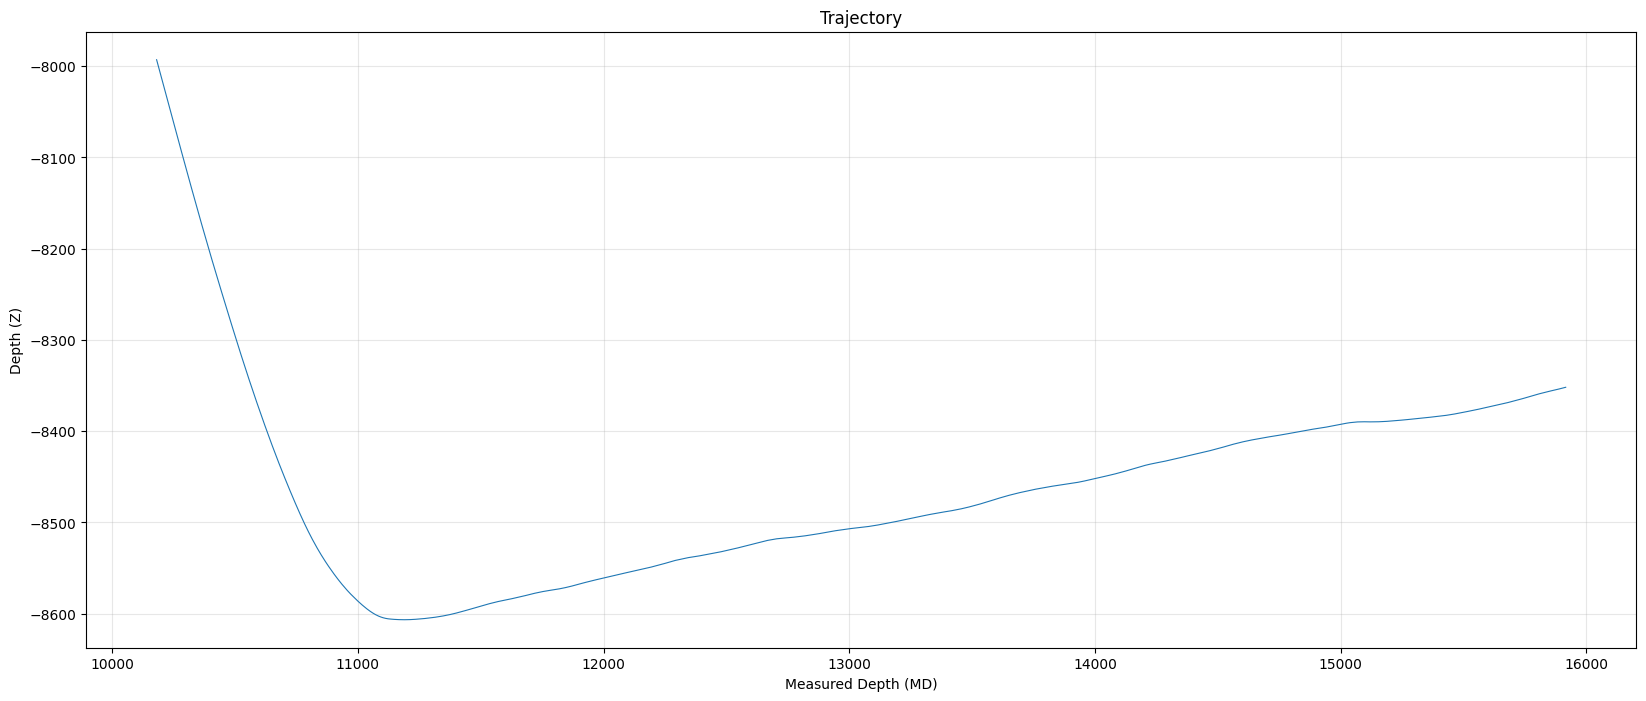

In [ ]:
# y against x
plot_x_y(h_df['MD'], h_df['Z'], "Measured Depth (MD)", "Depth (Z)", "Trajectory")

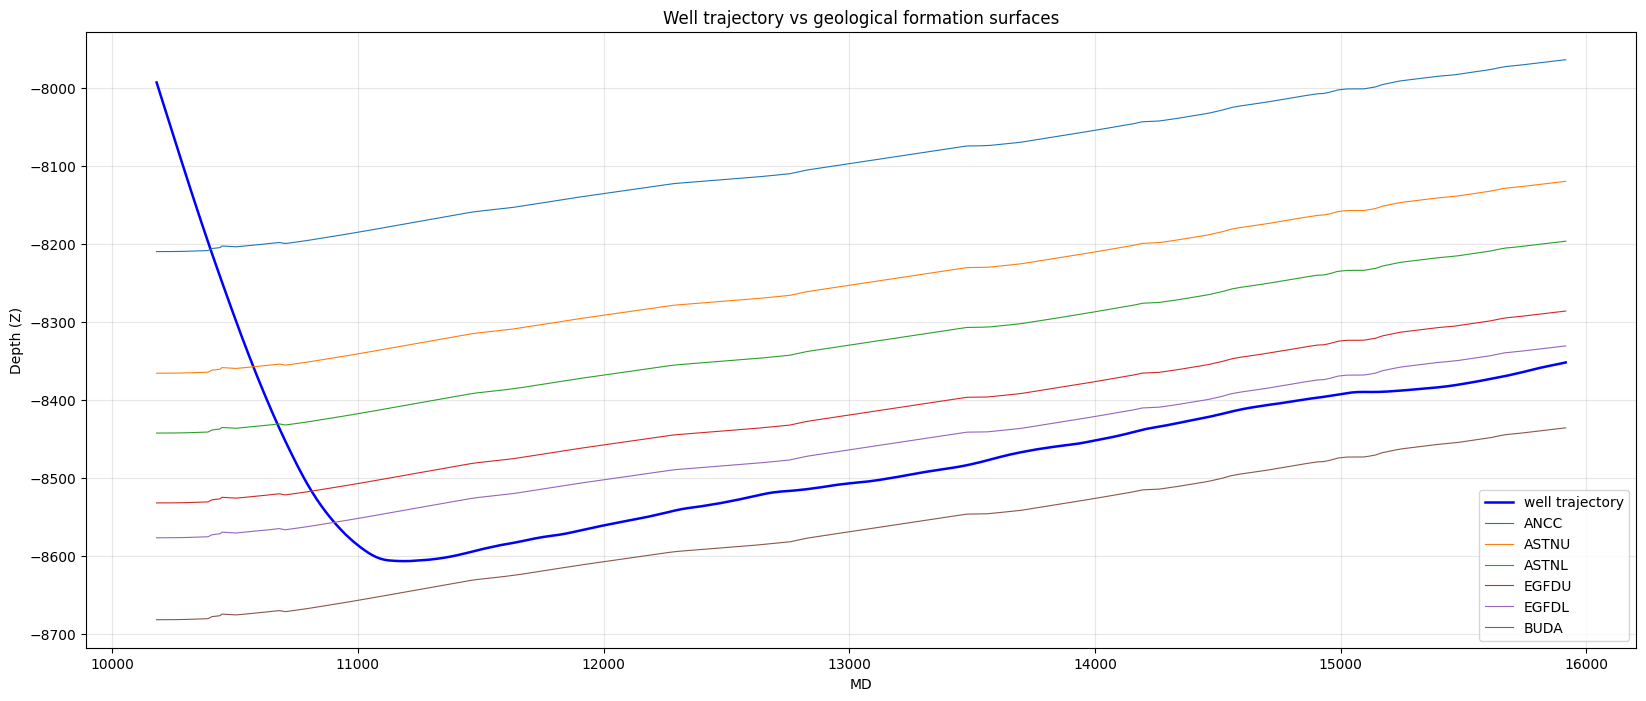

In [ ]:
plt.figure(figsize=(20, 8))
plt.plot(h_df['MD'], h_df['Z'], linewidth=1.8, label='well trajectory', color='blue')
plt.plot(h_df['MD'], h_df['ANCC'], linewidth=0.8, label='ANCC')
plt.plot(h_df['MD'], h_df['ASTNU'], linewidth=0.8, label='ASTNU')
plt.plot(h_df['MD'], h_df['ASTNL'], linewidth=0.8, label='ASTNL')
plt.plot(h_df['MD'], h_df['EGFDU'], linewidth=0.8, label='EGFDU')
plt.plot(h_df['MD'], h_df['EGFDL'], linewidth=0.8, label='EGFDL')
plt.plot(h_df['MD'], h_df['BUDA'], linewidth=0.8, label='BUDA')
plt.xlabel("MD")
plt.ylabel("Depth (Z)")
plt.title("Well trajectory vs geological formation surfaces")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

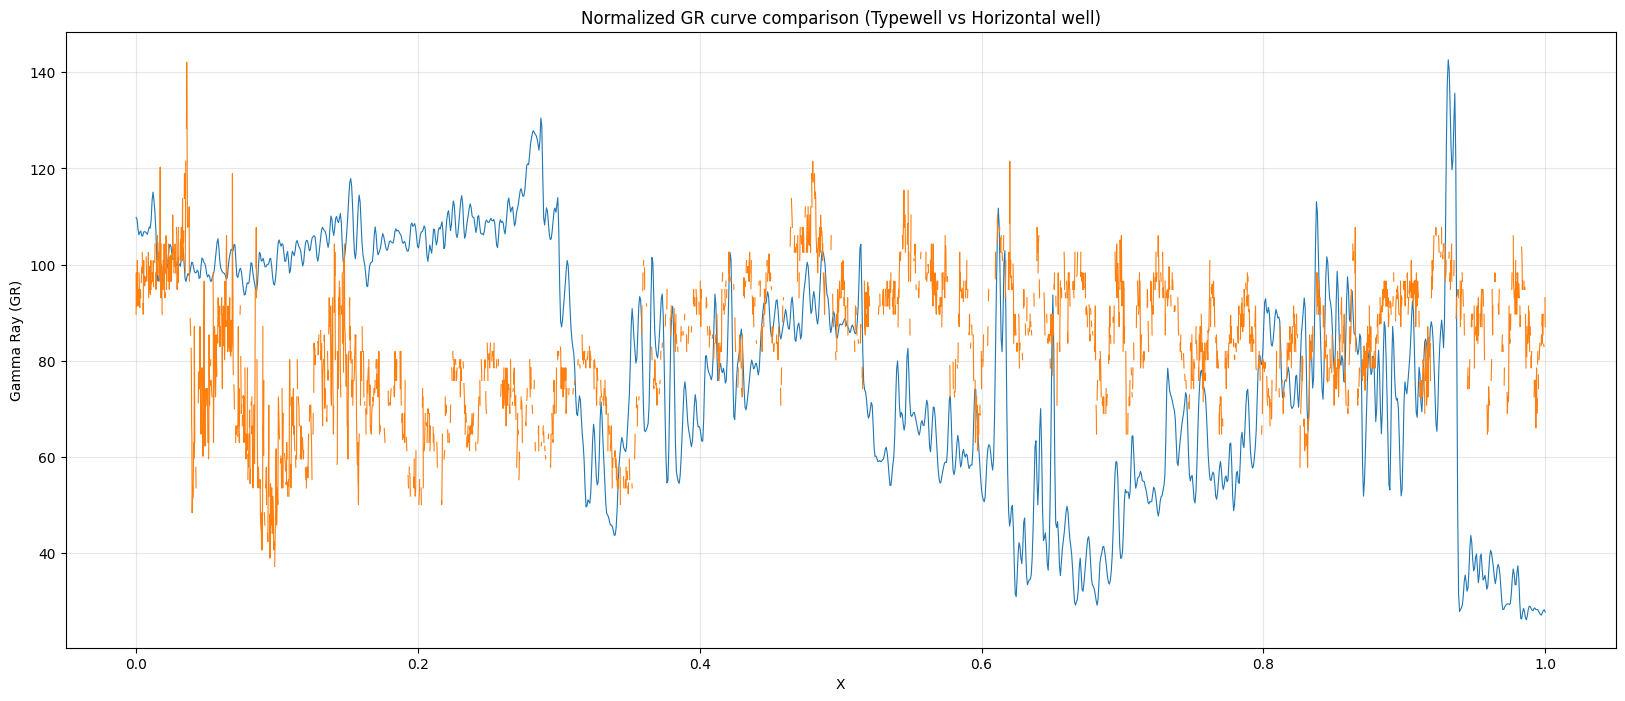

In [ ]:
# Quick visual check: do the two GR curves have a similar shape/pattern?
# This does NOT find the actual TVT match — it's just eyeballing texture before
# building the real sliding-window correlation function.

# normalising for a cleaner look
tw_norm = (tw_df['TVT']- tw_df['TVT'].min())/ (tw_df['TVT'].max() - tw_df['TVT'].min())
h_norm = (h_df['MD'] - h_df['MD'].min()) / (h_df['MD'].max() - h_df['MD'].min())

#plotting
plt.figure(figsize = (20,8))
plt.plot(tw_norm, tw_df['GR'], linewidth = 0.8 , label = 'Typewell GR')
plt.plot(h_norm, h_df['GR'], linewidth = 0.8, label = 'Horizontal Well GR')
plt.xlabel("X")
plt.ylabel("Gamma Ray (GR)")
plt.title("Normalized GR curve comparison (Typewell vs Horizontal well)")
plt.grid(True, alpha = 0.3)
plt.show()


# 3. Data Proprocessing

Before we can train anything, we need to turn each well's raw files into one clean table the model can actually learn from. Here's what we're doing for each well:

**Matching horizontal well points to the typewell.**
The horizontal well and typewell are two separate logs — they don't line up row by row, so we can't just merge them directly. Instead, we slide the horizontal well's GR curve across the typewell's GR curve to find where the patterns line up best (cross-correlation). Wherever we find a strong match, we grab the corresponding TVT from the typewell and attach it to that row, along with a score telling us how confident that match is.

**Adding a few engineered features.**
Since the data is sequential (each row depends a bit on the ones around it), we add some rolling-window features — basically local averages/trends over the last few rows — so the model gets a sense of what's happening nearby, not just at a single isolated point.

**Not bothering with missing values.**
There are NaNs scattered through the data, but we're not filling or dropping them — LightGBM handles missing values on its own during training, so it's one less thing to worry about.

**One exception: GR needs to be NaN-free just for the matching step.**
Cross-correlation breaks completely if there's even one NaN in the window, so we make a separate interpolated copy of GR purely to run the matching on. We don't touch the original GR column — that one keeps its real gaps and is what actually goes into the model.

In [ ]:
# function to normalize arrays
def normalize(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-8)

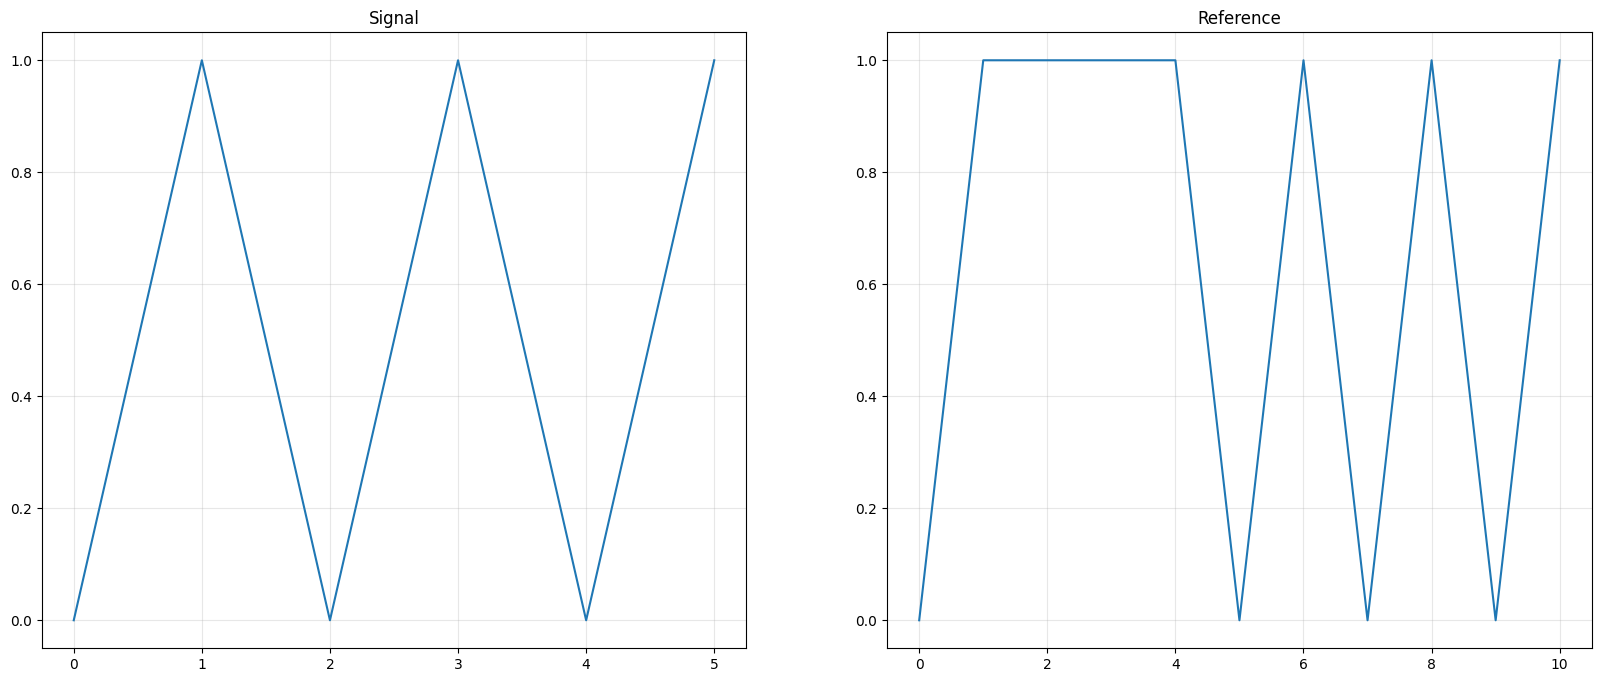

Correlation values:  [ 0.          2.07880452 -4.15760903  4.15760903 -6.23641355  6.23641355]
matched_place:  5


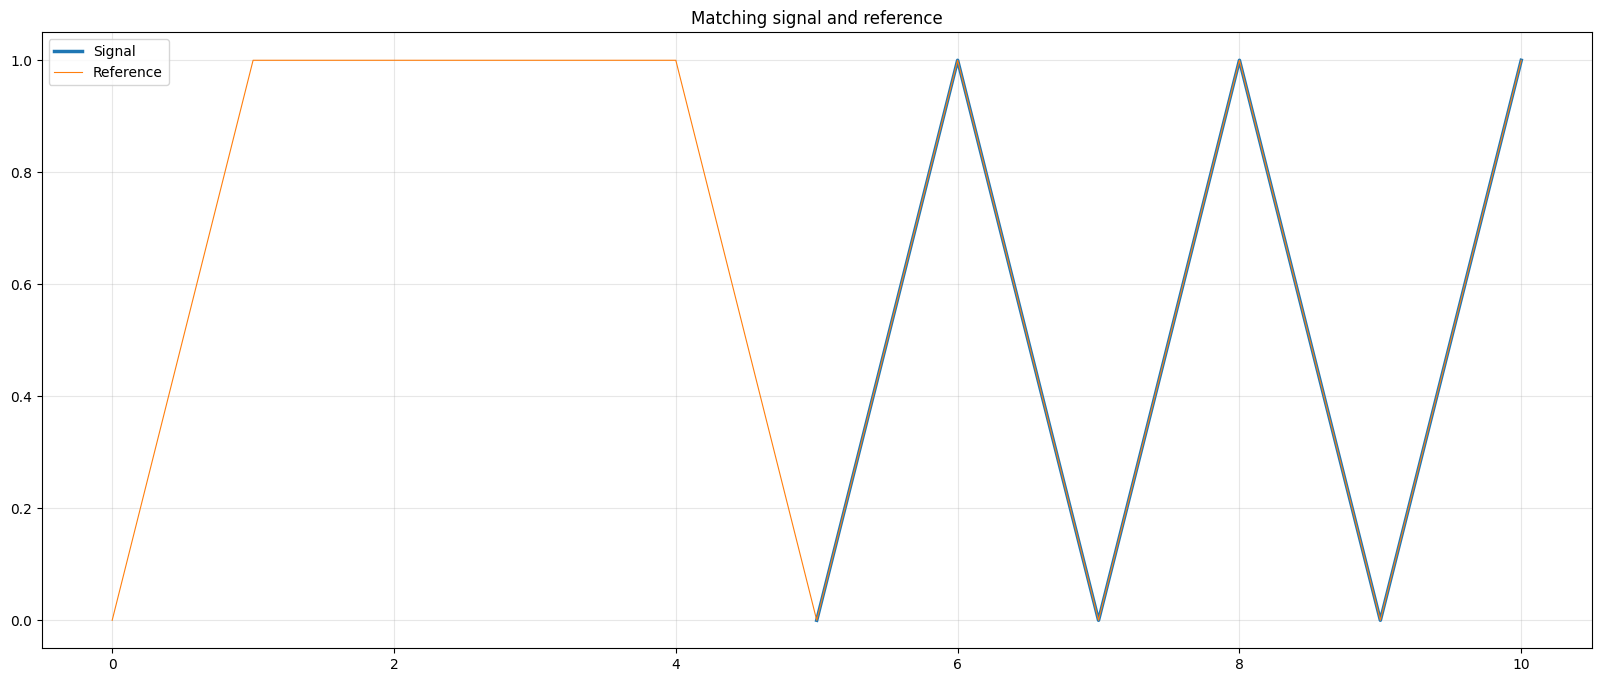

In [ ]:
# dummy example to understand scipy.signal.correlate()
signal = np.array([0,1,0,1,0,1], dtype = int)
reference = np.array([0,1,1,1,1,0,1,0,1,0,1], dtype = int) # where we are looking for similar patterns

# plotting the two before matching
plt.figure(figsize = (20,8))
plt.subplot(1,2,1)
plt.plot(signal)
plt.title("Signal")
plt.grid(True, alpha = 0.3)
plt.subplot(1,2,2)
plt.plot(reference)
plt.title("Reference")
plt.grid(True, alpha = 0.3)
plt.show()

n_signal = normalize(signal)
n_reference = normalize(reference)

corr = correlate(n_reference, n_signal, mode = 'valid')
print("Correlation values: ", corr)
matched_place = np.argmax(corr) # where the signal starts matching the reference
print("matched_place: ", matched_place)


# x axis
signal_x = np.arange(matched_place, matched_place + len(signal)) # this is for shifting to start from matched place
reference_x = np.arange(len(reference))

# plotting
plt.figure(figsize= (20,8))
plt.plot(signal_x, signal, linewidth = 2.5, label = 'Signal')
plt.plot(reference_x, reference, linewidth = 0.8, label = 'Reference')
plt.title("Matching signal and reference")
plt.grid(True, alpha = 0.3)
plt.legend()
plt.show()

### Applying this to the real data.

We'll do the same thing with the actual GR values: use matched_place to find the corresponding index in the typewell, then pull out its TVT and assign it to that row in the horizontal well dataset.


The difference is we won't take the whole array of GR values — we'll slide a small window of GR values at a time, for more precision. Each window produces one matched TVT and one confidence/correlation score, which we'll store in two new columns: matched_tvt and match_score.


Since each window covers several rows but only produces one matched value, we'll assign that value to the center row of the window, rather than to every row it covers — that gives the most representative position for the match. Do not worry about the rest of Matched TVT rows, they will get filled as the window slides :)

In [ ]:
# creating a function to process each well datasets separately.
def process_well(h_df, tw_df):
    # remove nan from GR columns first for cross correlation
    h_GR_clean = h_df['GR'].interpolate(limit_direction = 'both')
    tw_GR_clean = tw_df['GR'].interpolate(limit_direction= 'both')

    norm_h_GR = normalize(h_GR_clean)
    norm_tw_GR = normalize(tw_GR_clean)

    # initialise the new columns in horizontal file
    # (We use temporary NumPy arrays here for lightning-fast loop writes)
    matched_TVT_arr = np.full(len(norm_h_GR), np.nan)
    matched_score_arr = np.full(len(norm_h_GR), np.nan)
    tw_TVT_arr = tw_df['TVT'].to_numpy() # Converted to array to avoid .iloc slowdown

    # cross-correlation
    for i in range(0,len(norm_h_GR)- WINDOW):
        h_seq = norm_h_GR[i:i + WINDOW]
        corr = correlate(norm_tw_GR, h_seq, mode = 'valid')
        matched_place = np.argmax(corr)
        confidence_score = corr[matched_place]
        centre = (i + WINDOW ) // 2


        # assign it to columns
        # (Writing to the NumPy arrays instead of using slower .loc and .iloc)
        matched_TVT_arr[centre] = tw_TVT_arr[(matched_place + WINDOW) // 2]
        matched_score_arr[centre] = confidence_score

    # Assign the fast arrays back to the DataFrame columns once the loop is done
    h_df['matched_TVT'] = matched_TVT_arr
    h_df['matched_score'] = matched_score_arr

    # add rolling window features
    #GR
    h_df['GR_mean'] = h_df['GR'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).mean()
    h_df['GR_std'] = h_df['GR'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).std()
    # later if we are not sure which rolling window value is the best, we run a loop to add features
    # with more options (e.g. 10, 20, 100) and let the model decide with feature importance!

    #Z slope
    h_df['Z_slope'] = h_df['Z'].diff(10) / h_df['MD'].diff(10)
    h_df['Z_slope_mean'] = h_df['Z_slope'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).mean()
    h_df['Z_slope_std'] = h_df['Z_slope'].rolling(ROLLING_WINDOW, min_periods = 1, center = True).std()


    return h_df

In [ ]:
# process and concatenate all wells
df = []
for h_file in tqdm(HORIZONTAL_FILES):
    well_ID = os.path.basename(h_file).split("__")[0]
    tw_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")
    h_df = pd.read_csv(h_file)
    tw_df = pd.read_csv(tw_file)

    # process the data
    processed_df = process_well(h_df, tw_df)
    df.append(processed_df)

# concatenate everything
data = pd.concat(df, ignore_index = True)

  0%|          | 0/773 [00:00<?, ?it/s]

In [ ]:
data.head(50)

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,matched_TVT,matched_score,GR_mean,GR_std,Z_slope,Z_slope_mean,Z_slope_std
0,11663.0,2999945.15,1090240.89,-9410.08,-9402.89,-9547.57,-9579.66,-9695.42,-9731.81,-9869.40,11862.35,84.588494,11862.35,NaN,NaN,74.561435,17.670097,NaN,-0.899200,0.001304
1,11664.0,2999944.87,1090241.21,-9410.98,-9403.08,-9547.76,-9579.85,-9695.62,-9732.00,-9869.60,11863.06,99.206886,11863.06,NaN,NaN,74.976221,16.983804,NaN,-0.898833,0.001472
2,11665.0,2999944.59,1090241.53,-9411.89,-9402.88,-9547.56,-9579.65,-9695.41,-9731.80,-9869.39,11864.17,100.421534,11864.17,NaN,NaN,74.976221,16.983804,NaN,-0.898429,0.001718
3,11666.0,2999944.30,1090241.86,-9412.79,-9402.67,-9547.35,-9579.44,-9695.21,-9731.59,-9869.19,11865.28,78.504601,11865.28,NaN,NaN,75.002214,16.317801,NaN,-0.898000,0.002000
4,11667.0,2999944.02,1090242.18,-9413.69,-9402.47,-9547.15,-9579.24,-9695.00,-9731.39,-9868.98,11866.38,58.771903,11866.38,NaN,NaN,75.088671,15.727791,NaN,-0.897556,0.002297
5,11668.0,2999943.73,1090242.51,-9414.59,-9402.26,-9546.94,-9579.03,-9694.80,-9731.18,-9868.77,11867.49,54.137063,11867.49,NaN,NaN,75.209603,15.202188,NaN,-0.897100,0.002601
6,11669.0,2999943.44,1090242.83,-9415.49,-9402.05,-9546.73,-9578.82,-9694.59,-9730.97,-9868.57,11868.60,NaN,11868.60,NaN,NaN,75.044923,14.735107,NaN,-0.896636,0.002908
7,11670.0,2999943.15,1090243.16,-9416.39,-9401.84,-9546.52,-9578.61,-9694.38,-9730.76,-9868.36,11869.71,53.401881,11869.71,NaN,NaN,74.655257,14.390432,NaN,-0.896250,0.003079
8,11671.0,2999942.86,1090243.49,-9417.29,-9401.63,-9546.31,-9578.40,-9694.17,-9730.55,-9868.15,11870.81,55.841831,11870.81,NaN,NaN,74.255577,14.093082,NaN,-0.895769,0.003419
9,11672.0,2999942.57,1090243.82,-9418.19,-9401.42,-9546.10,-9578.19,-9693.96,-9730.34,-9867.94,11871.92,58.281782,11871.92,NaN,NaN,74.321525,13.720369,NaN,-0.895357,0.003629


In [ ]:
data.shape

(5092255, 20)

In [ ]:
# prepare the input to the models
X = data.drop(columns = ['TVT', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA'])
y = data['TVT']

# temp = test + val
X_train , X_temp,y_train ,  y_temp = train_test_split(X, y, test_size = 0.3, random_state = 42)
X_test , X_val ,  y_test,y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42)

X_train = X_train.values
X_test = X_test.values
X_val = X_val.values
y_train = y_train.values
y_test = y_test.values
y_val = y_val.values

print("X_train shape: ", X_train.shape )
print("y_train shape: ", y_train.shape )
print("X_test shape: ", X_test.shape )
print("y_test shape: ", y_test.shape )
print("X_val shape: ", X_val.shape )
print("y_val shape: ",y_val.shape )

X_train shape:  (3564578, 13)
y_train shape:  (3564578,)
X_test shape:  (763838, 13)
y_test shape:  (763838,)
X_val shape:  (763839, 13)
y_val shape:  (763839,)


# 4. Modeling

In [ ]:
!pip install catboost -q

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from numpy.lib.stride_tricks import sliding_window_view
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# check if a GPU is attached in this session - CatBoost can use it if so
catboost_gpu_available = False
try:
    import subprocess
    subprocess.check_output(['nvidia-smi'])
    catboost_gpu_available = True
except Exception:
    catboost_gpu_available = False
print("GPU available:", catboost_gpu_available)

GPU available: True


In [ ]:

if 'data' not in dir() or 'WELL_ID' not in data.columns:
    print("data missing or missing WELL_ID - rebuilding now...")
    df = []
    for h_file in tqdm(HORIZONTAL_FILES):
        well_ID = os.path.basename(h_file).split("__")[0]
        tw_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")
        h_df = pd.read_csv(h_file)
        tw_df = pd.read_csv(tw_file)
        h_df['WELL_ID'] = well_ID

        processed_df = process_well(h_df, tw_df)
        df.append(processed_df)

    data = pd.concat(df, ignore_index=True)

    X = data.drop(columns=['TVT', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA'])
    y = data['TVT']

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    X_train = X_train.values
    X_test = X_test.values
    X_val = X_val.values
    y_train = y_train.values
    y_test = y_test.values
    y_val = y_val.values

    print("rebuild done. WELL_ID in data:", 'WELL_ID' in data.columns)
else:
    print("data already has WELL_ID, continuing...")

# well-level split so sequence windows can't straddle train/test
well_ids = data['WELL_ID'].unique()
train_wells, temp_wells = train_test_split(well_ids, test_size=0.3, random_state=42)
val_wells, test_wells = train_test_split(temp_wells, test_size=0.5, random_state=42)

data_sorted = data.sort_values(['WELL_ID', 'MD']).reset_index(drop=True)
feature_cols = [c for c in X.columns if c != 'WELL_ID']

train_df = data_sorted[data_sorted['WELL_ID'].isin(train_wells)]
val_df   = data_sorted[data_sorted['WELL_ID'].isin(val_wells)]
test_df  = data_sorted[data_sorted['WELL_ID'].isin(test_wells)]

SEQ_LEN = 30

def build_well_sequences(df, feature_cols, seq_len):
    feats = df[feature_cols].fillna(0).values.astype('float32')
    target = df['TVT'].values.astype('float32')
    padded = np.vstack([np.zeros((seq_len - 1, feats.shape[1]), dtype='float32'), feats])
    windows = sliding_window_view(padded, seq_len, axis=0).transpose(0, 2, 1)
    return windows, target

def build_dataset_sequences(df, feature_cols, seq_len):
    X_list, y_list = [], []
    for well_id, group in tqdm(df.groupby('WELL_ID')):
        Xw, yw = build_well_sequences(group, feature_cols, seq_len)
        X_list.append(Xw)
        y_list.append(yw)
    return np.concatenate(X_list), np.concatenate(y_list)

X_train_seq, y_train_seq = build_dataset_sequences(train_df, feature_cols, SEQ_LEN)
X_val_seq, y_val_seq     = build_dataset_sequences(val_df, feature_cols, SEQ_LEN)
X_test_seq, y_test_seq   = build_dataset_sequences(test_df, feature_cols, SEQ_LEN)

feat_mean = X_train_seq.reshape(-1, X_train_seq.shape[-1]).mean(axis=0)
feat_std = X_train_seq.reshape(-1, X_train_seq.shape[-1]).std(axis=0) + 1e-8

X_train_seq_n = (X_train_seq - feat_mean) / feat_std
X_val_seq_n   = (X_val_seq - feat_mean) / feat_std
X_test_seq_n  = (X_test_seq - feat_mean) / feat_std

print("X_train_seq shape:", X_train_seq.shape)

data missing or missing WELL_ID - rebuilding now...


  0%|          | 0/773 [00:00<?, ?it/s]

rebuild done. WELL_ID in data: True


  0%|          | 0/541 [00:00<?, ?it/s]

  0%|          | 0/116 [00:00<?, ?it/s]

  0%|          | 0/116 [00:00<?, ?it/s]

X_train_seq shape: (3564218, 30, 13)


In [ ]:
cat_features = [X.columns.get_loc('WELL_ID')]

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val,  cat_features=cat_features)

cb_model = CatBoostRegressor(
    iterations=4000,
    learning_rate=0.03,
    depth=10,
    l2_leaf_reg=3,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=200,
    task_type='GPU' if catboost_gpu_available else 'CPU',
    verbose=200
)
cb_model.fit(train_pool, eval_set=val_pool, use_best_model=True)

cb_preds = cb_model.predict(X_test)
mae = mean_absolute_error(y_test, cb_preds)
rmse = mean_squared_error(y_test, cb_preds) ** 0.5
r2 = r2_score(y_test, cb_preds)
print(f"CatBoost -> MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.3f}")

0:	learn: 621.8575227	test: 621.6253543	best: 621.6253543 (0)	total: 402ms	remaining: 26m 47s
200:	learn: 65.4038566	test: 64.6638936	best: 64.6638936 (200)	total: 56.3s	remaining: 17m 44s
400:	learn: 44.5181315	test: 43.7614855	best: 43.7614855 (400)	total: 1m 51s	remaining: 16m 41s
600:	learn: 33.3269610	test: 32.5562509	best: 32.5562509 (600)	total: 2m 48s	remaining: 15m 50s
800:	learn: 27.1880175	test: 26.4706997	best: 26.4706997 (800)	total: 3m 44s	remaining: 14m 55s
1000:	learn: 23.0511877	test: 22.3281358	best: 22.3281358 (1000)	total: 4m 40s	remaining: 14m
1200:	learn: 20.0651840	test: 19.3656747	best: 19.3656747 (1200)	total: 5m 37s	remaining: 13m 6s
1400:	learn: 17.8690346	test: 17.2290628	best: 17.2290628 (1400)	total: 6m 34s	remaining: 12m 11s
1600:	learn: 16.2001016	test: 15.6217835	best: 15.6217835 (1600)	total: 7m 30s	remaining: 11m 15s
1800:	learn: 14.8858340	test: 14.3566275	best: 14.3566275 (1800)	total: 8m 27s	remaining: 10m 19s
2000:	learn: 13.8934646	test: 13.40925

In [ ]:
n_features = X_train_seq_n.shape[-1]

gru_model = Sequential([
    Bidirectional(GRU(128, return_sequences=True), input_shape=(SEQ_LEN, n_features)),
    Dropout(0.25),
    Bidirectional(GRU(64, return_sequences=True)),
    Dropout(0.25),
    Bidirectional(GRU(32)),
    Dense(32, activation='relu'),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

gru_model.fit(
    X_train_seq_n, y_train_seq,
    validation_data=(X_val_seq_n, y_val_seq),
    epochs=80, batch_size=512, callbacks=callbacks, verbose=1
)

gru_preds = gru_model.predict(X_test_seq_n, verbose=0).flatten()
mae = mean_absolute_error(y_test_seq, gru_preds)
rmse = mean_squared_error(y_test_seq, gru_preds) ** 0.5
r2 = r2_score(y_test_seq, gru_preds)
print(f"Bidirectional GRU -> MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.3f}")

I0000 00:00:1784663040.812317      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13754 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784663040.820567      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13754 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(SEQ_LEN, n_features)),
    Dropout(0.25),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.25),
    Bidirectional(LSTM(32)),
    Dense(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

lstm_model.fit(
    X_train_seq_n, y_train_seq,
    validation_data=(X_val_seq_n, y_val_seq),
    epochs=80, batch_size=512, callbacks=callbacks, verbose=1
)

lstm_preds = lstm_model.predict(X_test_seq_n, verbose=0).flatten()
mae = mean_absolute_error(y_test_seq, lstm_preds)
rmse = mean_squared_error(y_test_seq, lstm_preds) ** 0.5
r2 = r2_score(y_test_seq, lstm_preds)
print(f"Bidirectional LSTM -> MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.3f}")

In [ ]:
# refit CatBoost on the well-based split so it's directly comparable/stackable with the GRU
cb_stack_model = CatBoostRegressor(
    iterations=3000, learning_rate=0.03, depth=10, l2_leaf_reg=3,
    loss_function='RMSE', eval_metric='RMSE',
    random_seed=42, early_stopping_rounds=200, verbose=200
)
cb_stack_model.fit(
    Pool(train_df[feature_cols], train_df['TVT']),
    eval_set=Pool(val_df[feature_cols], val_df['TVT']),
    use_best_model=True
)

# reuse the GRU already trained in Model 2 - no need to retrain it here
cb_val_preds = cb_stack_model.predict(val_df[feature_cols])
gru_val_preds = gru_model.predict(X_val_seq_n, verbose=0).flatten()

meta_model = LinearRegression()
meta_model.fit(np.column_stack([cb_val_preds, gru_val_preds]), val_df['TVT'].values)

cb_test_preds = cb_stack_model.predict(test_df[feature_cols])
gru_test_preds = gru_model.predict(X_test_seq_n, verbose=0).flatten()
stacked_preds = meta_model.predict(np.column_stack([cb_test_preds, gru_test_preds]))

y_test_true = test_df['TVT'].values
for name, preds, yt in [
    ("CatBoost only", cb_test_preds, y_test_true),
    ("GRU only", gru_test_preds, y_test_true),
    ("LSTM only", lstm_preds, y_test_seq),
    ("Stacked (CatBoost+GRU)", stacked_preds, y_test_true)
]:
    mae = mean_absolute_error(yt, preds)
    rmse = mean_squared_error(yt, preds) ** 0.5
    r2 = r2_score(yt, preds)
    print(f"{name:24s} -> MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.3f}")